<a href="https://colab.research.google.com/github/LunaTic-Neon/2026-1-NLP/blob/main/26_1_0410_NLP_w6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. 필수 라이브러리 설치
!pip install konlpy pyLDAvis

import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
from konlpy.tag import Okt
from gensim import corpora
from gensim.models import LsiModel, LdaModel, CoherenceModel
import warnings

warnings.filterwarnings('ignore')

# 2. 데이터 로드
url = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt"
df = pd.read_csv(url, sep='\t')

# 3. 데이터 샘플링
df = df.dropna().sample(5000, random_state=42)
print(f"데이터 로드 완료. 샘플 수: {len(df)}")

데이터 로드 완료. 샘플 수: 5000


In [2]:
okt = Okt()
stopwords = ['영화', '정말', '진짜', '너무', '점', '진심', '내', '것', '이', '그', '데', '좀', '수']

def preprocess(text):
    # 명사만 추출
    tokens = okt.nouns(text)
    # 불용어 제거, 1글자 단어 제거
    tokens = [word for word in tokens if word not in stopwords and len(word) > 1]
    return tokens

print("데이터 전처리 중...")
df['tokens'] = df['document'].apply(preprocess)

# 빈 리스트 제거
df = df[df['tokens'].map(len) > 0]

# Gensim 사전, 코퍼스 생성
dictionary = corpora.Dictionary(df['tokens'])
# 너무 드물거나 흔한 단어 필터링
dictionary.filter_extremes(no_below=2, no_above=0.5)
corpus = [dictionary.doc2bow(text) for text in df['tokens']]

print(f"전처리 완료. 고유 단어 수: {len(dictionary)}")

데이터 전처리 중...
전처리 완료. 고유 단어 수: 2126


LSI 모델 평가 중...
Topics: 2 완료
Topics: 4 완료
Topics: 6 완료
Topics: 8 완료
Topics: 10 완료
LDA 모델 평가 중...
Topics: 2 완료
Topics: 4 완료
Topics: 6 완료
Topics: 8 완료
Topics: 10 완료


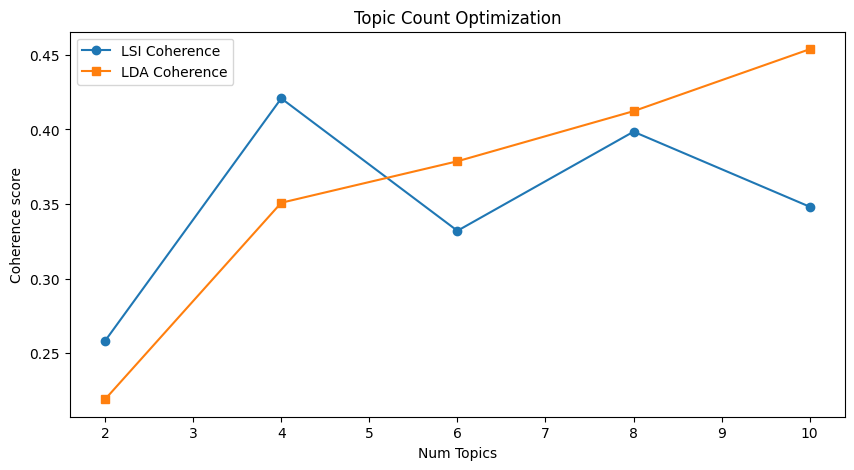

In [5]:
def compute_coherence_values(model_type, dictionary, corpus, texts, limit, start=2, step=2):
    coherence_values = []
    model_list = []
    for num_topics in range(start, limit, step):
        if model_type == 'LSI':
            model = LsiModel(corpus=corpus, num_topics=num_topics, id2word=dictionary)
        else:
            model = LdaModel(corpus=corpus, num_topics=num_topics, id2word=dictionary, passes=10, random_state=42)

        model_list.append(model)
        coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
        coherence_values.append(coherencemodel.get_coherence())
        print(f"Topics: {num_topics} 완료")
    return model_list, coherence_values

# 토픽 수 2개부터 10개까지 2씩 증가하며 확인
start, limit, step = 2, 12, 2
print("LSI 모델 평가 중...")
lsi_models, lsi_coherence = compute_coherence_values('LSI', dictionary, corpus, df['tokens'].tolist(), limit, start, step)
print("LDA 모델 평가 중...")
lda_models, lda_coherence = compute_coherence_values('LDA', dictionary, corpus, df['tokens'].tolist(), limit, start, step)

# 결과 시각화
x = range(start, limit, step)
plt.figure(figsize=(10, 5))
plt.plot(x, lsi_coherence, label='LSI Coherence', marker='o')
plt.plot(x, lda_coherence, label='LDA Coherence', marker='s')
plt.xlabel("Num Topics")
plt.ylabel("Coherence score")
plt.legend()
plt.title("Topic Count Optimization")
plt.show()

In [6]:
# 1. 최적의 토픽 수 선택
best_lsi_idx = np.argmax(lsi_coherence)
best_lda_idx = np.argmax(lda_coherence)

# 2. 인덱스를 바탕으로 실제 최적 토픽 개수 역산
optimal_lsi_k = start + best_lsi_idx * step
optimal_lda_k = start + best_lda_idx * step

def print_top_words(model, title, optimal_k):
    print(f"\n[{title} (최적 토픽 수: {optimal_k}개) - 상위 10개 단어]")

    topics = model.show_topics(num_topics=-1, num_words=10, formatted=False)

    for i, topic in topics:
        words = ", ".join([word for word, prob in topic])
        print(f"Topic {i + 1}: {words}")

# 3. 결과 출력
print_top_words(lsi_models[best_lsi_idx], "최적 LSI 모델", optimal_lsi_k)
print_top_words(lda_models[best_lda_idx], "최적 LDA 모델", optimal_lda_k)


[최적 LSI 모델 (최적 토픽 수: 4개) - 상위 10개 단어]
Topic 1: 평점, 생각, 드라마, 최고, 스토리, 사람, 연기, 보고, 배우, 감동
Topic 2: 평점, 연기, 최고, 드라마, 배우, 스토리, 보고, 알바, 감독, 사람
Topic 3: 사람, 최고, 드라마, 평점, 생각, 사랑, 보고, 그냥, 배우, 여자
Topic 4: 연기, 최고, 스토리, 배우, 드라마, 사람, 감동, 보고, 사랑, 평점

[최적 LDA 모델 (최적 토픽 수: 10개) - 상위 10개 단어]
Topic 1: 최고, 감독, 인생, 하나, 이상, 지금, 드라마, 스토리, 아주, 웃기
Topic 2: 이건, 사람, 이영화, 설정, 스토리, 무슨, 웃음, 전개, 알바, 그냥
Topic 3: 보고, 배우, 연기, 완전, 드라마, 전혀, 마음, 내용, 막장, 요즘
Topic 4: 재미, 스토리, 결말, 액션, 내용, 스릴러, 이야기, 감독, 명작, 인상
Topic 5: 평점, 생각, 반전, 보고, 그냥, 내내, 다큐, 감독, 지루함, 시작
Topic 6: 시간, 작품, 여자, 남자, 느낌, 눈물, 몰입, 한국, 기대, 연기
Topic 7: 감동, 사랑, 생각, 최악, 이해, 명작, 사람, 역시, 엄마, 계속
Topic 8: 원작, 별로, 아이, 기억, 주인공, 모습, 성룡, 언제, 연출, 작가
Topic 9: 다시, 처음, 매력, 장면, 코미디, 중간, 마지막, 대사, 캐릭터, 연기
Topic 10: 쓰레기, 내용, 가슴, 개봉, 전쟁, 대박, 이제, 시리즈, 영화관, 점도
